# Analyse des clusters d'interaction actine

**Objectif** : à partir de `filtered_all_data.csv`, grouper les interactions par cluster de séquence, calculer des stats de fréquence des résidus d'interface, et représenter chaque cluster sous forme de graphe NetworkX.

**Rappel** : chaque ligne de `filtered_all_data.csv` est un **représentant d'interaction** (pas une moyenne). Les résidus d'interface viennent de `details/` et les contacts sont toujours **S1 (actine) ↔ S2 (partenaire)** — les deux côtés sont donc nécessaires pour les arêtes du graphe.

## 0. Imports et chemins

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import textwrap
from matplotlib.lines import Line2D
import os
import re

DETAILS_PATH    = "../data/filtered/details"

ALL_DATA        = "../data/filtered/filtered_all_data.csv"
SUMMARY         = "../data/filtered/filtered_summary.csv"
INTERACTIONS_1  = os.path.join(DETAILS_PATH, "1.interactions.csv")
INTER_RES_4     = os.path.join(DETAILS_PATH, "4.inter-residue_contacts.csv")

## 1. Chargement données

In [130]:
# all data filtré
df_all = pd.read_csv(ALL_DATA, sep=",")
print(df_all.columns)
print(f"ALL_DATA --> Lignes : {len(df_all)}  |  PDB uniques : {df_all['pdb_id'].nunique()}")
print(df_all.columns, "\n")

# summary filtré
df_summary = pd.read_csv(SUMMARY)
print(f"SUMMARY --> Lignes : {len(df_summary)}  |  PDB uniques : {df_summary['PDB ID'].nunique()}")
print(df_summary.columns, "\n")

## details filtrés
# table 1 interactions
df_interactions = pd.read_csv(INTERACTIONS_1)
print("df_interactions :", df_interactions.shape)
print(df_interactions.columns, "\n")
# table 4 inter-residus
df_res = pd.read_csv(INTER_RES_4)
print("df_res :", df_res.shape)
print(df_res.columns, "\n")



Index(['pdb_id', 'release_date', 'biounit_no', 'resolution', 'pdb_annotation',
       'protein_peptide_interaction', 'protein_nucleic_interaction',
       'protein_protein_interaction', 'domain_domain_interaction', 'subunit_1',
       's1_protein_type', 'subunit_1_title', 'scop_family_1', 's1_taxonomy_id',
       's1_number_of_residues', 's1_sequence', 's1_sequence_cluster_95',
       's1_sequence_cluster_70', 's1_sequence_cluster_40', 'subunit_2',
       's2_protein_type', 'subunit_2_title', 'scop_family_2', 's2_taxonomy_id',
       's2_number_of_residues', 's2_sequence', 's2_sequence_cluster_95',
       's2_sequence_cluster_70', 's2_sequence_cluster_40', 'area',
       'number_of_contacts', 's1_number_of_visible_residues',
       's2_number_of_visible_residues', 'number_of_interface_ligands', 'homo',
       'cluster_data_95', 's1_binding_site_cluster_data_95',
       's2_binding_site_cluster_data_95', 'cluster_data_70',
       's1_binding_site_cluster_data_70', 's2_binding_site_clust

In [131]:
with open(ALL_DATA) as f:
    lines = f.readlines()
print(lines[374])  # ligne 375 (0-indexé)


7r8v,2021-07-28,1,2.82,Cryo-EM structure of the ADP state actin filament,0,0,1,0,7r8v_B,protein,"Actin, alpha skeletal muscle, intermediate form",,9031.0,371,TTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVMVGMGQKDSYVGDEAQSKRGILTLKYPIEHGIITNWDDMEKIWHHTFYNELRVAPEEHPTLLTEAPLNPKANREKMTQIMFETFNVPAMYVAIQAVLSLYASGRTTGIVLDSGDGVTHNVPIYEGYALPHAIMRLDLAGRDLTDYLMKILTERGYSFVTTAEREIVRDIKEKLCYVALDFENEMATAASSSSLEKSYELPDGQVITIGNERFRCPETLFQPSFIGMESAGIHETTYNSIMKCDIDIRKDLYANNVMSGGTTMYPGIADRMQKEITALAPSTMKIKIIAPPERKYSVWIGGSILASLSTFQQMWITKQEYDEAGPSIVHRKCF,11314,6685,5147,7r8v_A,protein,"Actin, alpha skeletal muscle, intermediate form",,9031.0,371,TTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVMVGMGQKDSYVGDEAQSKRGILTLKYPIEHGIITNWDDMEKIWHHTFYNELRVAPEEHPTLLTEAPLNPKANREKMTQIMFETFNVPAMYVAIQAVLSLYASGRTTGIVLDSGDGVTHNVPIYEGYALPHAIMRLDLAGRDLTDYLMKILTERGYSFVTTAEREIVRDIKEKLCYVALDFENEMATAASSSSLEKSYELPDGQVITIGNERFRCPETLFQPSFIGMESAGIHETTYNSIMKCDIDIRKDLYANNVMSGGTTMYPGIADRMQKEITALAPSTMKIKIIAPPERKYSVWIGGSILASLSTFQQMWITKQEYDEAGPSIVHRKCF,11314

In [132]:
print(len(df_all))
old_df = df_all.copy()
mask = (
    df_all['subunit_1_title'].str.contains('domain|fragment', case=False, na=False) |
    df_all['subunit_2_title'].str.contains('domain|fragment', case=False, na=False)
)
df_all = df_all[~mask]
print(f"Lignes restantes : {len(df_all)} ({len(df_all) - len(old_df)})" )

2392
Lignes restantes : 2363 (-29)


## Fonctions

## Tag des vrais actines

In [133]:
# actine reelle = expect value 0
df_summary["Expect value"] = df_summary["Expect value"].astype(float)
real_actin = df_summary[df_summary["Expect value"] == 0]["Result protein"].unique()
for actine in real_actin:
    print(actine)

# ajoute colone actine_tag dans all_data
df_all["s1_actine"] = df_all["subunit_1_title"].isin(real_actin)
df_all["s2_actine"] = df_all["subunit_2_title"].isin(real_actin)

Actin, cytoplasmic 1, N-terminally processed
Actin, alpha skeletal muscle
Actin-1
Actin, gamma-enteric smooth muscle
Actin, alpha cardiac muscle 1
Actin-2
Actin
ACTB protein (Fragment)
Actin, cytoplasmic 1
Actin, cytoplasmic 2
Actin, alpha skeletal muscle, intermediate form
Actin, alpha 1b, skeletal muscle
actin, cytoplasmic 1
ACTIN, ALPHA SKELETAL MUSCLE
pollen F-actin


## Quel seuil de cluster de similarité d'interface regroupe tout les actines ?

In [134]:
actine_df = df_all[df_all["s1_actine"] == True]

DF = actine_df

seuils = [95, 70, 40]
    
for seuil in seuils:
    cluster_col = f"s1_sequence_cluster_{seuil}"
    
    print(f"\n--- Cluster level {seuil}% ---")
    
    n_clusters = DF[cluster_col].nunique()
    
    print(f"Nombre de clusters contenant des actines : {n_clusters}")


--- Cluster level 95% ---
Nombre de clusters contenant des actines : 7

--- Cluster level 70% ---
Nombre de clusters contenant des actines : 2

--- Cluster level 40% ---
Nombre de clusters contenant des actines : 1


In [135]:
# Jointure et nettoyage

DF, df = actine_df, "actine_df"

print(f"Taille de DF: {len(DF)}")
print(f"Taille de summary: {len(df_summary)}")

df_merged = DF.merge(
    df_summary,
    left_on= ['subunit_1', 'subunit_2'],
    right_on = ['Protein ID', 'Interactor ID'],
    how='left'
)                                                      

print(f"{df} : {len(DF)} → merged: {len(df_merged)}")

df_merged["interaction_id"] = df_merged['Link to details'].str.split(" ").str[0].astype(int)

Taille de DF: 1871
Taille de summary: 3497
actine_df : 1871 → merged: 1871


## Un graphe par patch

Nombre de patchs avec graphe: 113 

       patch interaction_type  n_noeuds  n_arretes  n_interactions  \
5     6685_2             homo        11         11             477   
8     6685_4             homo        11         11             336   
6     6685_1             homo        11         11             215   
7     6685_3             homo        11         11             162   
16    6685_0           hetero         7          6              63   
15   6685_21           hetero         4          3              46   
3    6685_17             homo         3          3              41   
42  6685_141           hetero         5          3              28   
96  6685_257           hetero         4          2              23   
33  6685_121           hetero         6          4              23   

                                          s2_partners  n_s2_partners  
5                                                  []              0  
8                                                  

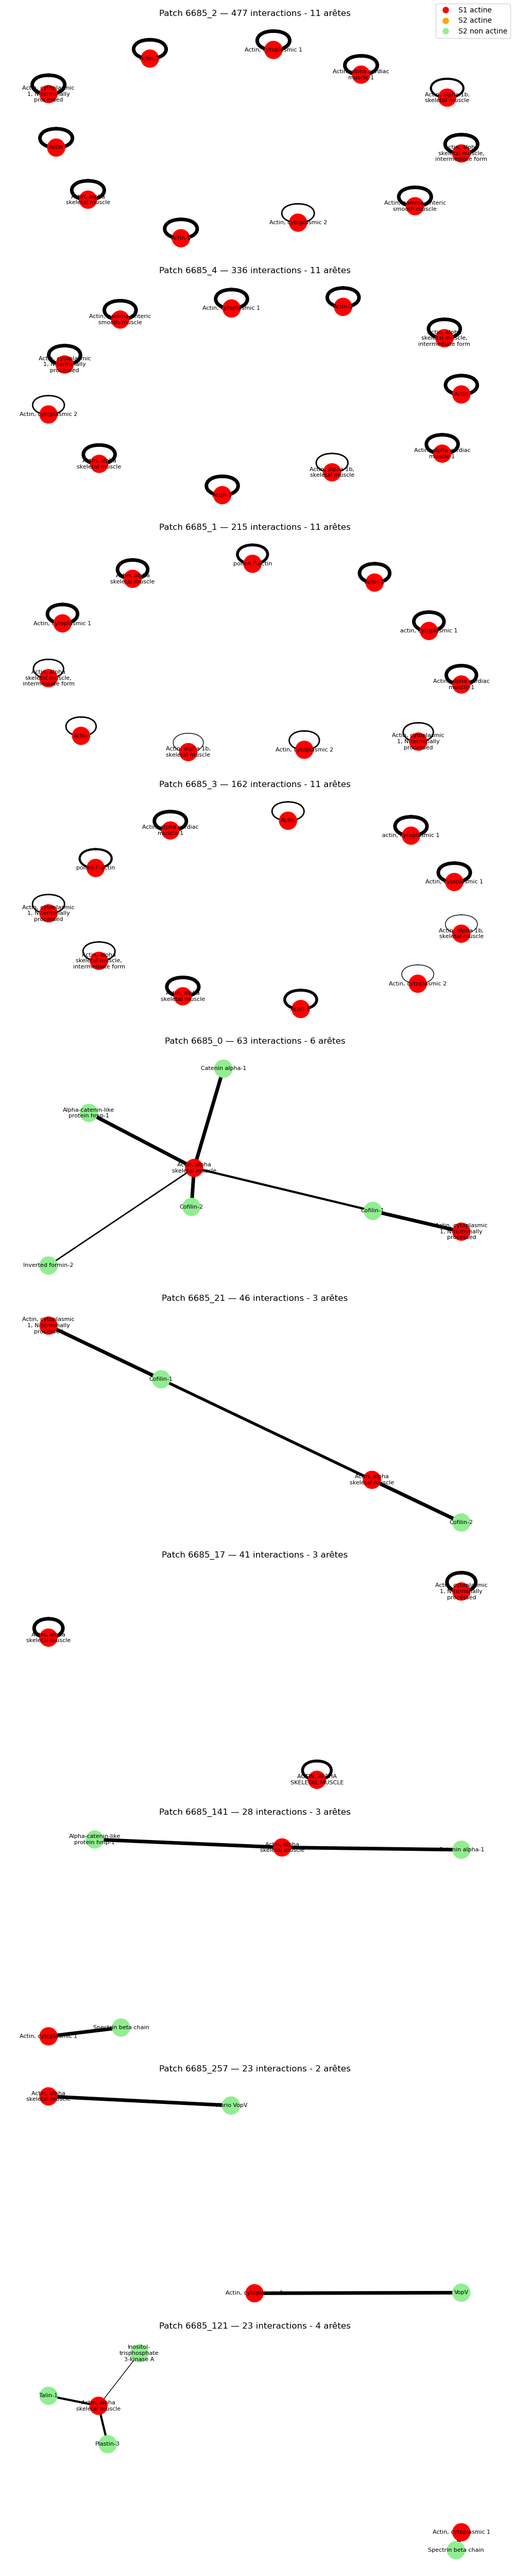

In [136]:
DF = df_merged

real_actine_subunits_1 = set(DF[DF["subunit_1_title"].isin(real_actin)]["subunit_1"].unique())
real_actine_subunits_2 = set(DF[DF["subunit_2_title"].isin(real_actin)]["subunit_2"].unique())


col_patch = "s1_binding_site_cluster_data_70"

patch_graphs = {}

for patch in DF[col_patch].unique():
    if pd.isna(patch):
        continue
    
    patch_data = DF[DF[col_patch] == patch]
    
    G = nx.Graph()
    
    has_homo = False
    for _, row in patch_data.iterrows():
        s1_title = row['subunit_1_title']
        s2_title = row['subunit_2_title']
        if pd.isna(s1_title) or pd.isna(s2_title):
            continue

        is_s1_actin = s1_title in real_actin
        is_s2_actin = s2_title in real_actin

        if not G.has_node(s1_title):
            G.add_node(s1_title, side='S1', is_actin=is_s1_actin)
        if not G.has_node(s2_title):
            G.add_node(s2_title, side='S2', is_actin=is_s2_actin)

        if G.has_edge(s1_title, s2_title):
            G[s1_title][s2_title]['weight'] += 1
        else:
            G.add_edge(s1_title, s2_title, weight=1)

        if is_s1_actin and is_s2_actin:
            has_homo = True
    
    G.graph['interaction_type'] = "homo" if has_homo else "hetero"
    patch_graphs[patch] = G

print(f"Nombre de patchs avec graphe: {len(patch_graphs)} \n")

patch_info = []
for patch, G in patch_graphs.items():
    patch_info.append({
        "patch": patch,
        "interaction_type": G.graph['interaction_type'],
        "n_noeuds": G.number_of_nodes(),
        "n_arretes": G.number_of_edges(),
        "n_interactions": len(DF[DF[col_patch] == patch]),
        "s2_partners": list(set(
            n for n, attr in G.nodes(data=True)
            if attr['side'] == 'S2' and not attr['is_actin']
        )),
        "n_s2_partners": len(list(set(
            n for n, attr in G.nodes(data=True)
            if attr['side'] == 'S2' and not attr['is_actin']
        )))    
        })

df_patches_infos = pd.DataFrame(patch_info)
df_patches_infos = df_patches_infos.sort_values("n_interactions", ascending=False)
print(df_patches_infos.head(10), "\n")
print(df_patches_infos["interaction_type"].value_counts())

top_patches = DF[col_patch].value_counts().head(10).index.tolist()
top_patches = [(patch, patch_graphs[patch]) for patch in top_patches if patch in patch_graphs]

fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(10, 50))

for i, (patch, G) in enumerate(top_patches):
    pos = nx.spring_layout(G)

    node_colors = []
    for n, d in G.nodes(data=True):
        if d['side'] == 'S1':
            node_colors.append('red')
        else:
            if n in real_actin:
                node_colors.append('orange')
            else:
                node_colors.append('lightgreen')

    labels = {n: textwrap.fill(n, width=20) for n in G.nodes()}
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    weights_norm = [min(w, 5) for w in weights]

    nx.draw(G, pos, node_color=node_colors, labels=labels,
            font_size=8, node_size=600, ax=axes[i], width=weights_norm)
    axes[i].set_title(f"Patch {patch} — {len(DF[DF[col_patch] == patch])} interactions - {G.number_of_edges()} arêtes",
                      fontsize=12)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',        markersize=10, label='S1 actine'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',     markersize=10, label='S2 actine'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label='S2 non actine'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()



## Version patch par interaction pdb

Nombre de patchs avec graphe: 113 

       patch interaction_type  n_noeuds  n_arretes  n_interactions  \
5     6685_2             homo       654        477             477   
8     6685_4             homo       530        336             336   
6     6685_1             homo       330        215             215   
7     6685_3             homo       280        162             162   
16    6685_0           hetero       126         63              63   
15   6685_21           hetero        92         46              46   
3    6685_17             homo        66         41              41   
42  6685_141           hetero        56         28              28   
96  6685_257           hetero        46         23              23   
33  6685_121           hetero        46         23              23   

                                          s2_partners  
5                                                  []  
8                                                  []  
6                        

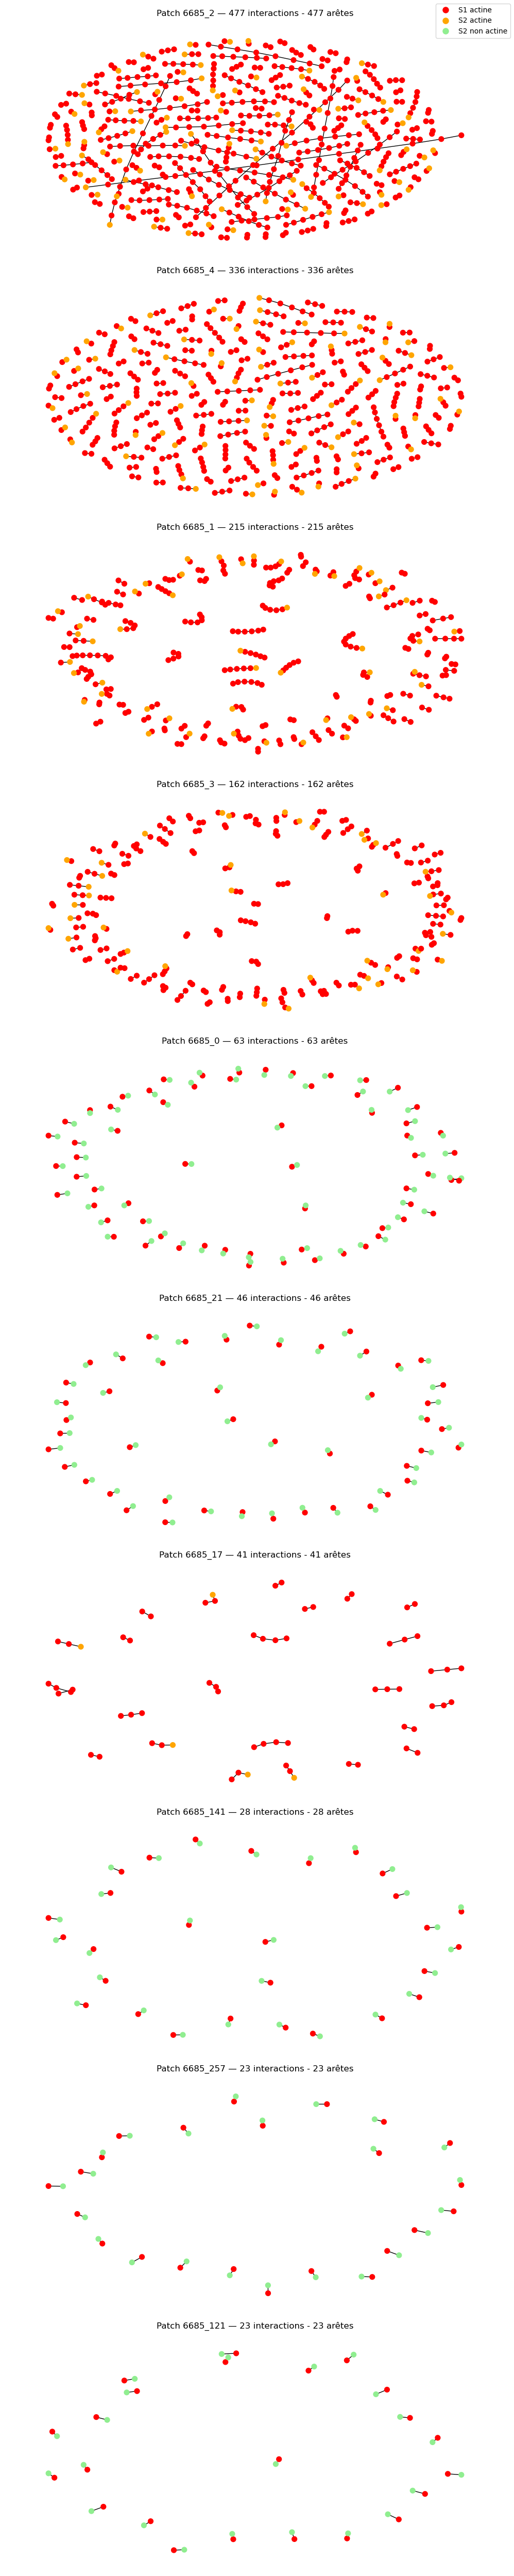

In [137]:
DF = df_merged

real_actine_subunits_1 = set(DF[DF["subunit_1_title"].isin(real_actin)]["subunit_1"].unique())
real_actine_subunits_2 = set(DF[DF["subunit_2_title"].isin(real_actin)]["subunit_2"].unique())

col_patch = "s1_binding_site_cluster_data_70"
subunit2_to_title = DF.set_index('subunit_2')['subunit_2_title'].to_dict()

patch_graphs = {}

for patch in DF[col_patch].unique():
    if pd.isna(patch):
        continue
    
    patch_data = DF[DF[col_patch] == patch]
    G = nx.Graph()
    has_homo = False

    for _, row in patch_data.iterrows():
        s1 = row['subunit_1']
        s2 = row['subunit_2']
        if pd.isna(s1) or pd.isna(s2):
            continue

        is_s1_actin = s1 in real_actine_subunits_1
        is_s2_actin = s2 in real_actine_subunits_2

        if not G.has_node(s1):
            G.add_node(s1, side='S1', is_actin=is_s1_actin)
        if not G.has_node(s2):
            G.add_node(s2, side='S2', is_actin=is_s2_actin)

        if G.has_edge(s1, s2):
            G[s1][s2]['weight'] += 1
        else:
            G.add_edge(s1, s2, weight=1)

        if is_s1_actin and is_s2_actin:
            has_homo = True

    G.graph['interaction_type'] = "homo" if has_homo else "hetero"
    patch_graphs[patch] = G

print(f"Nombre de patchs avec graphe: {len(patch_graphs)} \n")

patch_info = []
for patch, G in patch_graphs.items():
    patch_info.append({
        "patch": patch,
        "interaction_type": G.graph['interaction_type'],
        "n_noeuds": G.number_of_nodes(),
        "n_arretes": G.number_of_edges(),
        "n_interactions": len(DF[DF[col_patch] == patch]),
        "s2_partners": list(set(
            subunit2_to_title.get(n, n)
            for n, attr in G.nodes(data=True)
            if attr['side'] == 'S2' and not attr['is_actin']
        ))
    })

df_patches_infos = pd.DataFrame(patch_info)
df_patches_infos = df_patches_infos.sort_values("n_interactions", ascending=False)
print(df_patches_infos.head(10), "\n")
print(df_patches_infos["interaction_type"].value_counts())

top_patches = DF[col_patch].value_counts().head(10).index.tolist()
top_patches = [(patch, patch_graphs[patch]) for patch in top_patches if patch in patch_graphs]

fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(10, 50))

for i, (patch, G) in enumerate(top_patches):
    pos = nx.spring_layout(G)

    node_colors = []
    for n, d in G.nodes(data=True):
        if d['side'] == 'S1':
            node_colors.append('red')
        else:  # S2
            if n in real_actine_subunits_1:   # S2 qui est aussi actine S1
                node_colors.append('red')
            elif d['is_actin']:               # S2 actine (côté S2 uniquement)
                node_colors.append('orange')
            else:
                node_colors.append('lightgreen')


    nx.draw(G, pos, node_color=node_colors,
            font_size=8, node_size=50, ax=axes[i])
    axes[i].set_title(f"Patch {patch} — {len(DF[DF[col_patch] == patch])} interactions - {G.number_of_edges()} arêtes",
                      fontsize=12)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',        markersize=10, label='S1 actine'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',     markersize=10, label='S2 actine'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label='S2 non actine'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


## Graphe global : patchs S1 actine et partenaires S2

Nombre de patchs S1: 113
Nombre de partenaires S2 : 56
Partenaires S2 actine : 14


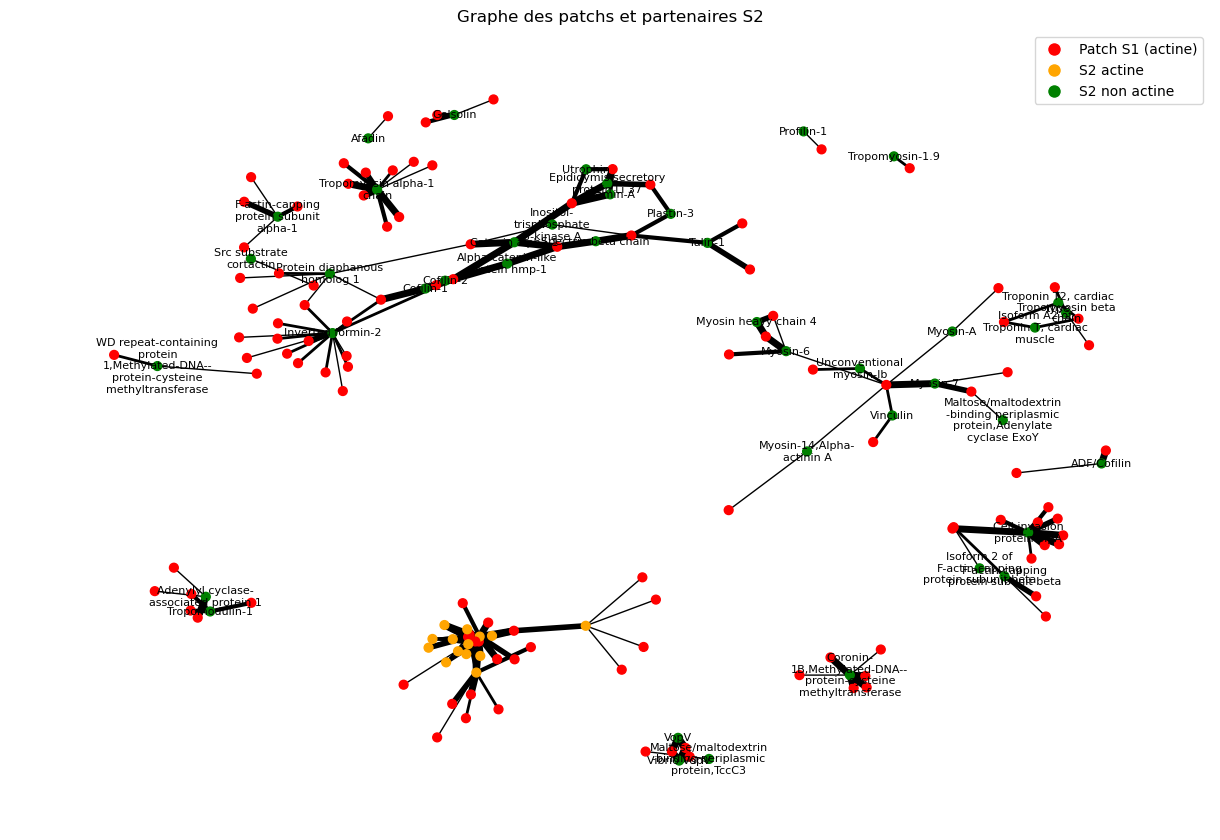

In [162]:
DF = df_merged

col_patch = "s1_binding_site_cluster_data_70"

G = nx.Graph()
for _, row in DF.iterrows():
    patch = row[col_patch]
    s2 = row['subunit_2_title']

    if pd.isna(patch) or pd.isna(s2):
        continue

    # Tous les patchs viennent de actine_df donc S1 est toujours actine
    G.add_node(patch, side="patch")

    # S2 est actine si son titre est dans real_actin
    is_s2_actin = s2 in real_actin
    if G.has_node(s2):
        G.nodes[s2]['is_actin'] = G.nodes[s2]['is_actin'] or is_s2_actin
    else:
        G.add_node(s2, side="s2", is_actin=is_s2_actin)

    if G.has_edge(patch, s2):
        G[patch][s2]['weight'] += 1
    else:
        G.add_edge(patch, s2, weight=1)


patches = [n for n, d in G.nodes(data=True) if d['side'] == 'patch']
nodes   = [n for n, d in G.nodes(data=True) if d['side'] == 's2']
print(f"Nombre de patchs S1: {len(patches)}")
print(f"Nombre de partenaires S2 : {len(nodes)}")
print(f"Partenaires S2 actine : {sum(d['is_actin'] for _, d in G.nodes(data=True) if d['side'] == 's2')}")

pos = nx.spring_layout(G, k = 0.6, iterations=200)
nodes_color = []
for n, d in G.nodes(data=True):
    if d['side'] == 'patch':
        nodes_color.append('red')       # toujours actine (filtré)
    else:
        nodes_color.append('orange' if d['is_actin'] else 'green')

weights      = [G[u][v]['weight'] for u, v in G.edges()]
weights_norm = [min(w, 5) for w in weights]
labels = {n: textwrap.fill(n, width=20)
          for n, d in G.nodes(data=True)
          if d['side'] == 's2' and not d['is_actin']}

plt.figure(figsize=(12, 8))
nx.draw(G, pos, node_color=nodes_color, node_size=40, width=weights_norm, labels=labels, font_size=8)
plt.title("Graphe des patchs et partenaires S2")
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Patch S1 (actine)',    markerfacecolor='red',    markersize=10),
    Line2D([0], [0], marker='o', color='w', label='S2 actine',            markerfacecolor='orange', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='S2 non actine',        markerfacecolor='green',  markersize=10),
]
plt.legend(handles=legend_elements, loc='upper right')
plt.show()


Chaque S2 partenaire est représenté qu'une fois
Ce sont les 113 patchs (points rouge) qui sont représentés

Vert entouré de rouge = interaction non spécifique ou grande interface d'interaction

In [139]:
print(DF[~DF["subunit_2_title"].isin(real_actin)]["subunit_2_title"].unique())

['Myosin-14,Alpha-actinin A' 'Unconventional myosin-Ib' 'Filamin-A'
 'Cofilin-1' 'Vinculin' 'Epididymis secretory protein Li 37' 'Myosin-A'
 'Myosin-7' 'Utrophin' 'Catenin alpha-1'
 'Maltose/maltodextrin-binding periplasmic protein,Adenylate cyclase ExoY'
 'ADF/Cofilin' 'Maltose/maltodextrin-binding periplasmic protein,TccC3'
 'Plastin-3' 'Tropomyosin alpha-1 chain' 'Troponin T2, cardiac type'
 'Alpha-catenin-like protein hmp-1' 'Spectrin beta chain'
 'Tropomyosin-1.9' 'Tropomodulin-1'
 'F-actin-capping protein subunit alpha-1'
 'F-actin-capping protein subunit beta' 'Cell invasion protein SipA'
 'Src substrate cortactin'
 'Isoform 2 of F-actin-capping protein subunit beta' 'Inverted formin-2'
 'Profilin-1' 'Protein diaphanous homolog 1' 'Gelsolin' 'Afadin'
 'Inositol-trisphosphate 3-kinase A' 'Myosin heavy chain 4'
 'Tropomyosin beta chain' 'Myosin-6' 'Talin-1'
 'Isoform A2 of Troponin T, cardiac muscle' 'VopV' 'Vibrio VopV'
 'Coronin-1B,Methylated-DNA--protein-cysteine methyltransfer

In [140]:
s2_cible = "Cofilin-1"

# patches qui contiennent ce S2
patches_connectes = DF[DF['subunit_2_title'] == s2_cible][col_patch].dropna().unique().tolist()
print(patches_connectes)

s2_cible_df = DF[
    DF[col_patch].isin(patches_connectes) &
    (DF['subunit_2_title'] == s2_cible)
]
print(s2_cible_df[['pdb_id', col_patch]])

cof = s2_cible_df.copy()
print(cof.groupby(col_patch)['pdb_id'].value_counts())


['6685_21', '6685_0', '6685_200']
     pdb_id s1_binding_site_cluster_data_70
149    6vao                         6685_21
151    6vao                          6685_0
152    6vao                         6685_21
154    6vao                         6685_21
156    6vao                         6685_21
157    6vao                          6685_0
158    6vao                          6685_0
1542   9qfd                         6685_21
1543   9qfd                        6685_200
1546   9qfd                         6685_21
1547   9qfd                        6685_200
1550   9qfd                         6685_21
1551   9qfd                        6685_200
1554   9qfd                         6685_21
1555   9qfd                        6685_200
1558   9qfd                         6685_21
1559   9qfd                        6685_200
1561   9qfd                         6685_21
1562   9qfd                         6685_21
1565   9qfe                         6685_21
1566   9qfe                          6685_

In [141]:
print(DF[DF['s1_binding_site_cluster_data_70'] == '10300_0'][['subunit_1_title', 'subunit_2_title', 'cluster_data_70']]) 

Empty DataFrame
Columns: [subunit_1_title, subunit_2_title, cluster_data_70]
Index: []


# Cluster_data_70 : patch par interaction

## Vue générale du truc

Nombre de patchs avec graphe: 163 

         patch interaction_type  n_noeuds  n_arretes  n_interactions  \
5     0_7797_0             homo        13         13             594   
6     0_7797_1             homo        12         12             481   
16   0_30351_1           hetero         4          3              56   
12   0_7797_12             homo         2          2              54   
145  0_7797_50             homo         1          1              47   
15   0_30351_0           hetero         4          3              46   
11   0_7797_10             homo         2          2              44   
146  0_84583_0           hetero         2          1              21   
148  0_84583_2           hetero         2          1              17   
147  0_84583_1           hetero         2          1              17   

     avg_contacts                                        s2_partners  \
5           47.70                                                 []   
6           47.90          

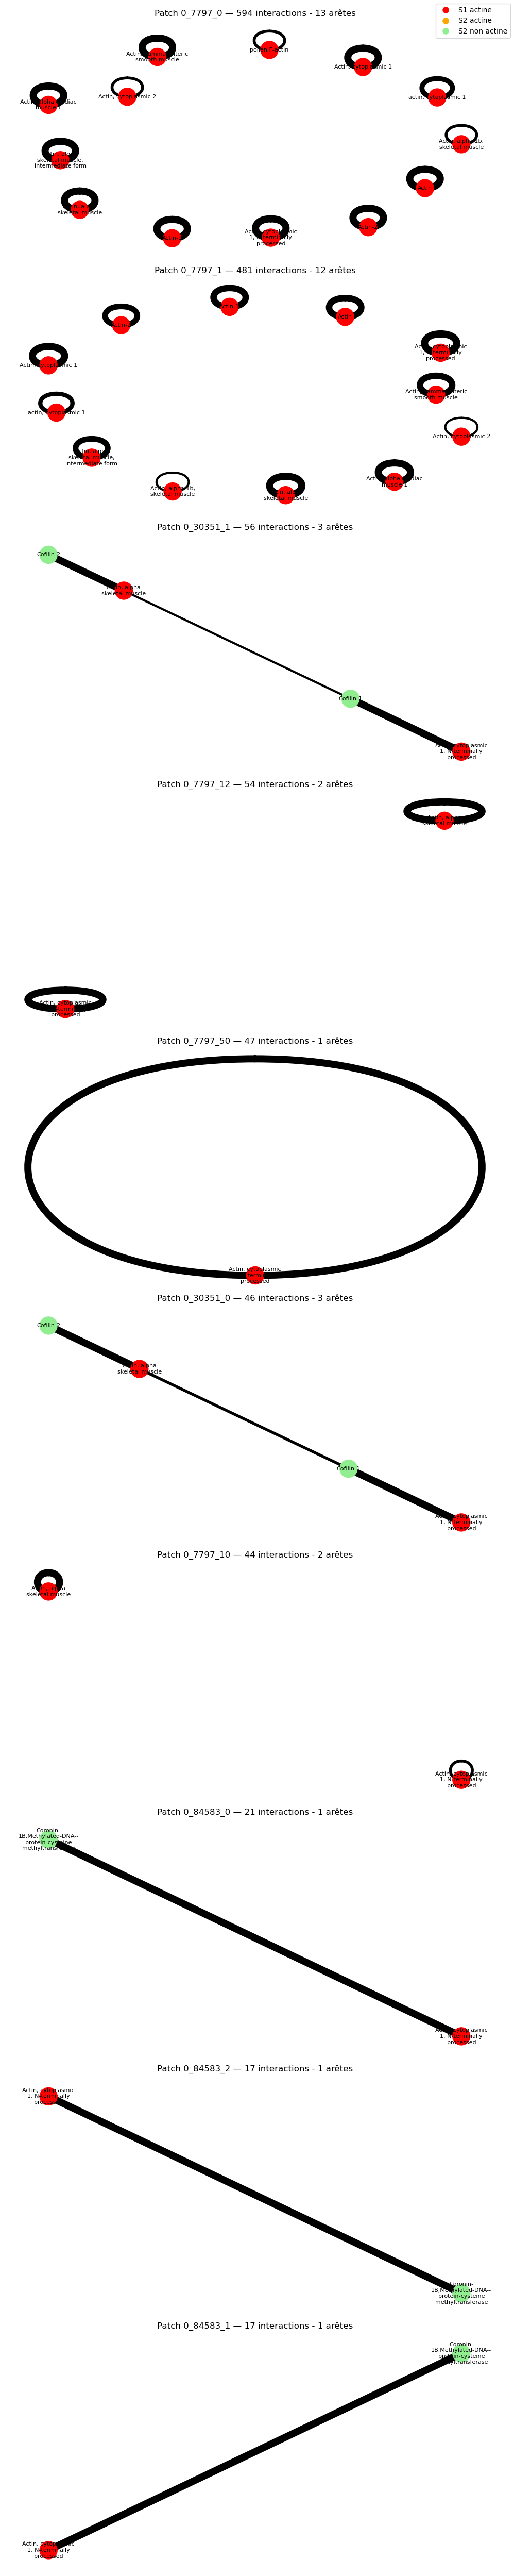

In [142]:
DF = df_merged
col_patch = "cluster_data_70"

patch_graphs = {}

for patch in DF[col_patch].unique():
    if pd.isna(patch):
        continue
    
    patch_data = DF[DF[col_patch] == patch]
    
    G = nx.Graph()
    
    has_homo = False
    for _, row in patch_data.iterrows():
        s1_title = row['subunit_1_title']
        s2_title = row['subunit_2_title']
        if pd.isna(s1_title) or pd.isna(s2_title):
            continue

        is_s1_actin = s1_title in real_actin
        is_s2_actin = s2_title in real_actin

        if not G.has_node(s1_title):
            G.add_node(s1_title, side='S1', is_actin=is_s1_actin)
        if not G.has_node(s2_title):
            G.add_node(s2_title, side='S2', is_actin=is_s2_actin)

        if G.has_edge(s1_title, s2_title):
            G[s1_title][s2_title]['weight'] += 1
        else:
            G.add_edge(s1_title, s2_title, weight=1)

        if is_s1_actin and is_s2_actin:
            has_homo = True
    
    G.graph['interaction_type'] = "homo" if has_homo else "hetero"
    patch_graphs[patch] = G

print(f"Nombre de patchs avec graphe: {len(patch_graphs)} \n")

patch_info = []
for patch, G in patch_graphs.items():
    ids = list(DF[DF[col_patch] == patch]["interaction_id"].unique())
    contacts = df_res[df_res['interaction_id'].isin(ids)]
    avg_contacts = len(contacts) / len(ids) if len(ids) > 0 else 0
    patch_info.append({
        "patch": patch,
        "interaction_type": G.graph['interaction_type'],
        "n_noeuds": G.number_of_nodes(),
        "n_arretes": G.number_of_edges(),
        "n_interactions": len(DF[DF[col_patch] == patch]),
        "avg_contacts": round(avg_contacts, 2),
        "s2_partners": list(set(
            n for n, attr in G.nodes(data=True)
            if attr['side'] == 'S2' and not attr['is_actin']
        )),
        "n_s2_partners": len(list(set(
            n for n, attr in G.nodes(data=True)
            if attr['side'] == 'S2' and not attr['is_actin']
        ))),
        "ids_interactions": ids
    })

df_patches_infos = pd.DataFrame(patch_info)
df_patches_infos = df_patches_infos.sort_values("n_interactions", ascending=False)
print(df_patches_infos.head(10), "\n")
print(df_patches_infos["interaction_type"].value_counts())

top_patches = DF[col_patch].value_counts().head(10).index.tolist()
top_patches = [(patch, patch_graphs[patch]) for patch in top_patches if patch in patch_graphs]

fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(10, 50))

for i, (patch, G) in enumerate(top_patches):
    pos = nx.spring_layout(G)

    node_colors = []
    s1 = []
    for n, d in G.nodes(data=True):
        if d['side'] == 'S1' and n in real_actin:
            node_colors.append('red')
            s1.append(n)
        else:
            if n in real_actin and n in s1:
                node_colors.append('red')
            elif n in real_actin:
                node_colors.append('orange')
            else:
                node_colors.append('lightgreen')

    labels = {n: textwrap.fill(n, width=20) for n in G.nodes()}
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    weights_norm = [min(w, 10) for w in weights]

    nx.draw(G, pos, node_color=node_colors, labels=labels,
            font_size=8, node_size=600, ax=axes[i], width=weights_norm)
    axes[i].set_title(f"Patch {patch} — {len(DF[DF[col_patch] == patch])} interactions - {G.number_of_edges()} arêtes",
                      fontsize=12)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',        markersize=10, label='S1 actine'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',     markersize=10, label='S2 actine'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label='S2 non actine'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()



## Réseaux residus

In [143]:
# filter
id_merge = list(df_merged["interaction_id"].sort_values())

print(len(df_interactions))
df_interactions = df_interactions[df_interactions['interaction_id'].isin(id_merge)]
print(len(df_interactions))

print(len(df_res))
df_res = df_res[df_res['interaction_id'].isin(id_merge)]
print(len(df_res))
print(df_res.columns)
print(df_res.head())

3497
1513
211395
91450
Index(['interaction_id', 'chain_A_id', 'residue_A_structure',
       'residue_A_sequence', 'residue_A_name', 'chain_B_id',
       'residue_B_structure', 'residue_B_sequence', 'residue_B_name',
       'contact_area', 'contact_type'],
      dtype='object')
     interaction_id chain_A_id  residue_A_structure  residue_A_sequence  \
130            1000     9duv_C                   39                  39   
131            1000     9duv_C                   39                  39   
132            1000     9duv_C                   39                  39   
133            1000     9duv_C                   39                  39   
134            1000     9duv_C                   40                  40   

    residue_A_name chain_B_id  residue_B_structure  residue_B_sequence  \
130              R     9duv_D                  265                 265   
131              R     9duv_D                  268                 268   
132              R     9duv_D                  26


Patch 0_7797_0 — 594 interactions | 463 avec contacts | 2482 nœuds (877 chaîne A, 1605 chaîne B) | 47.7 contacts résidus moyen | 6222 arêtes


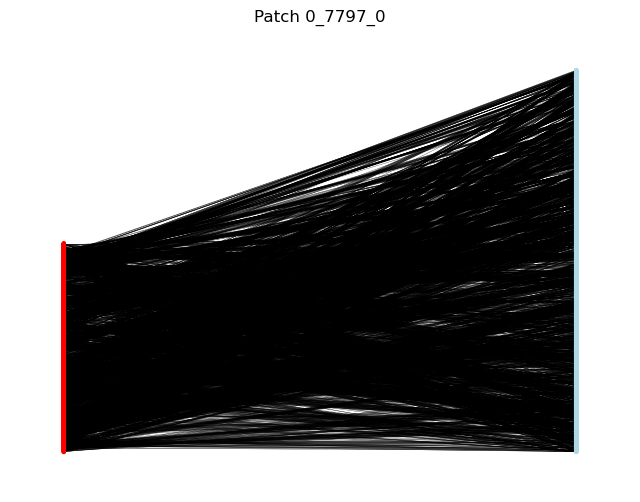


Patch 0_7797_1 — 481 interactions | 380 avec contacts | 2190 nœuds (764 chaîne A, 1426 chaîne B) | 47.9 contacts résidus moyen | 5431 arêtes


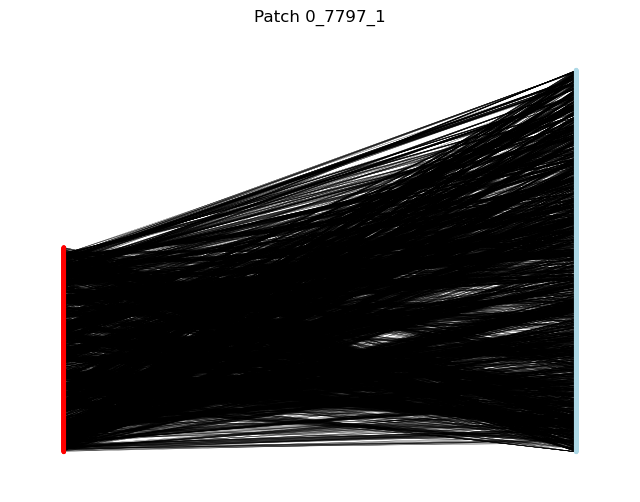


Patch 0_30351_1 — 56 interactions | 51 avec contacts | 647 nœuds (274 chaîne A, 373 chaîne B) | 51.96 contacts résidus moyen | 1195 arêtes


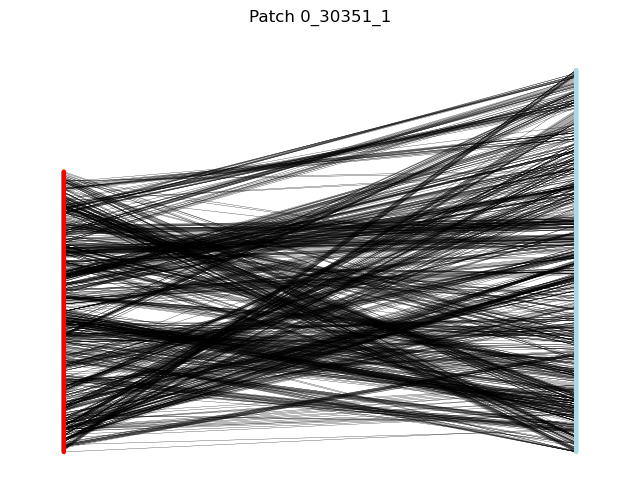


Patch 0_7797_12 — 54 interactions | 48 avec contacts | 721 nœuds (305 chaîne A, 416 chaîne B) | 54.98 contacts résidus moyen | 1334 arêtes


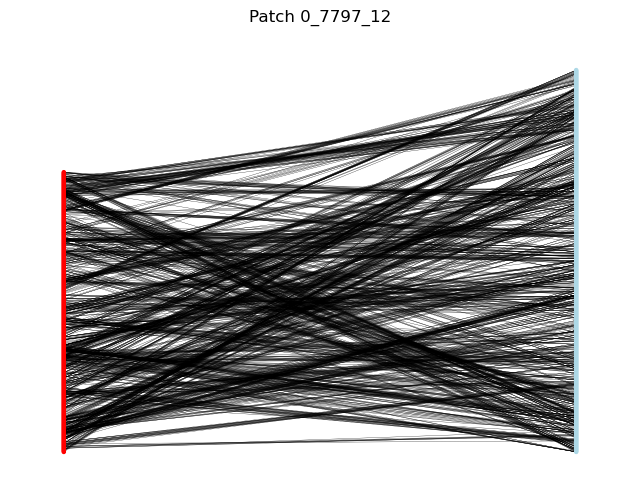


Patch 0_7797_50 — 47 interactions | 43 avec contacts | 679 nœuds (315 chaîne A, 364 chaîne B) | 53.4 contacts résidus moyen | 1184 arêtes


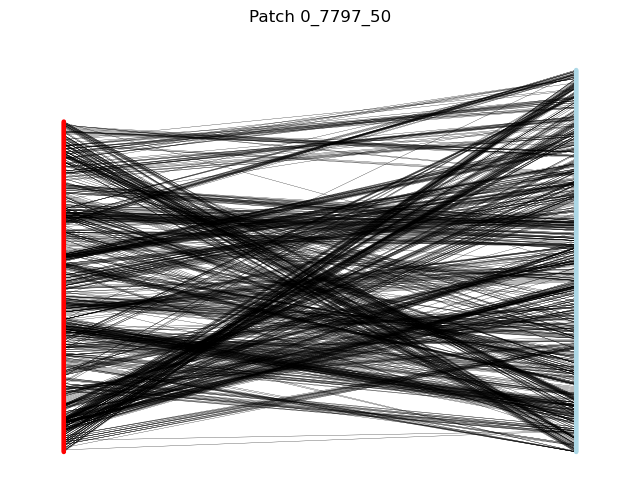


Patch 0_30351_0 — 46 interactions | 43 avec contacts | 603 nœuds (303 chaîne A, 300 chaîne B) | 51.78 contacts résidus moyen | 1052 arêtes


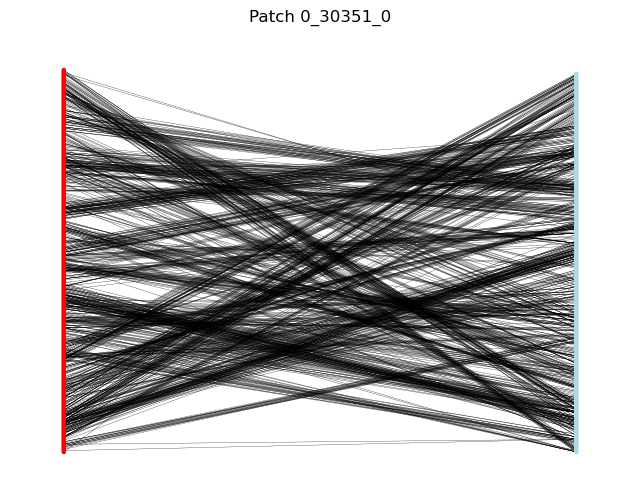


Patch 0_7797_10 — 44 interactions | 38 avec contacts | 528 nœuds (252 chaîne A, 276 chaîne B) | 49.02 contacts résidus moyen | 925 arêtes


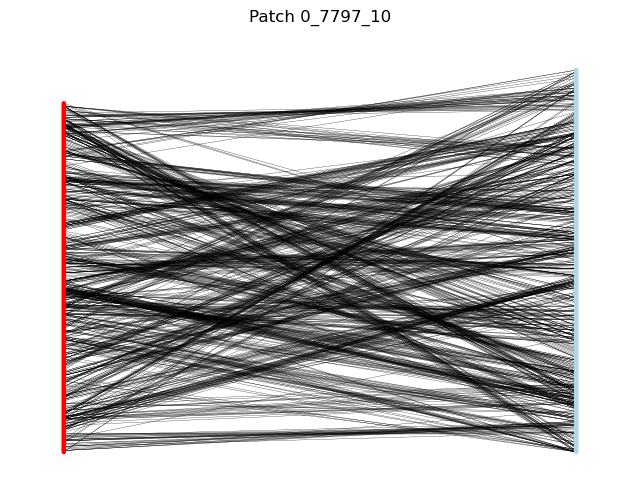


Patch 0_84583_0 — 21 interactions | 21 avec contacts | 466 nœuds (224 chaîne A, 242 chaîne B) | 60.62 contacts résidus moyen | 790 arêtes


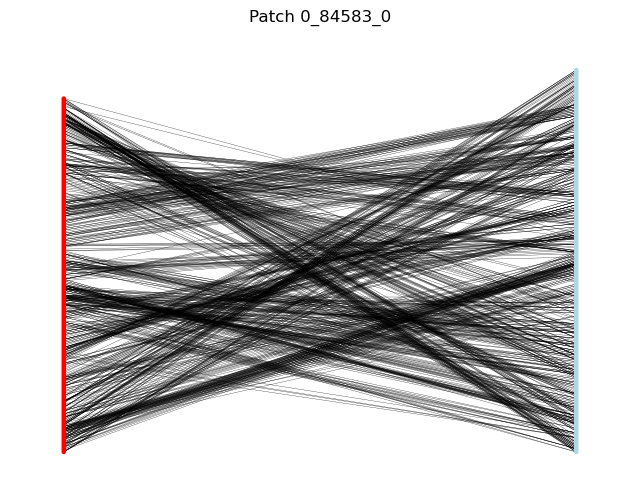


Patch 0_84583_2 — 17 interactions | 17 avec contacts | 506 nœuds (248 chaîne A, 258 chaîne B) | 54.94 contacts résidus moyen | 749 arêtes


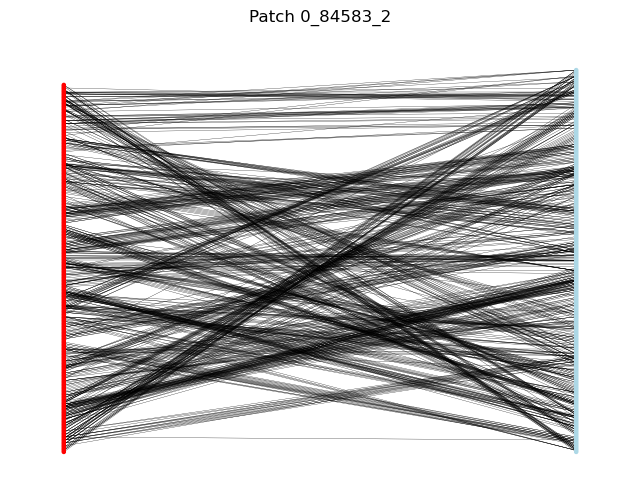


Patch 0_84583_1 — 17 interactions | 17 avec contacts | 309 nœuds (162 chaîne A, 147 chaîne B) | 53.65 contacts résidus moyen | 529 arêtes


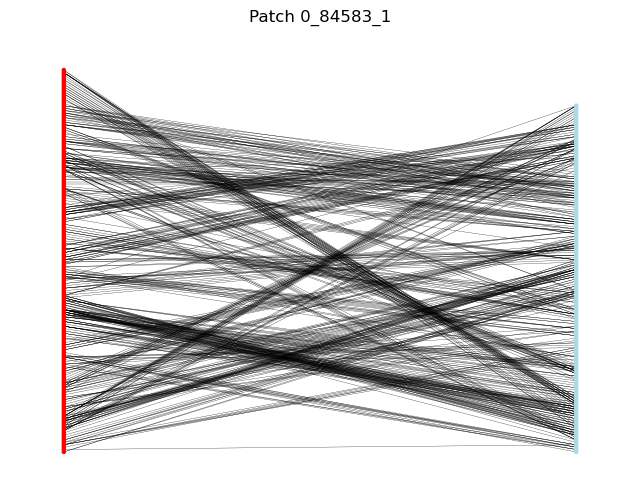

In [148]:
# Formation des reseaux d'interactions inter-residus par patch

N = 10

infos_patchs = df_patches_infos.head(N)

for _, patch_row in infos_patchs.iterrows():
    patch = patch_row['patch']
    ids = patch_row['ids_interactions']   # pas de [ ] autour
    contacts_moy = patch_row['avg_contacts']

    patch_contacts = df_res[df_res['interaction_id'].isin(ids)]

    G = nx.Graph()

    for _, row in patch_contacts.iterrows():
        name_a = f"{row['residue_A_name']}{row['residue_A_structure']}"
        name_b = f"{row['residue_B_name']}{row['residue_B_structure']}"
        node_a = f"A|{name_a}"
        node_b = f"B|{name_b}"
        G.add_node(node_a, side="A", label=name_a)
        G.add_node(node_b, side="B", label=name_b)
        if G.has_edge(node_a, node_b):
            G[node_a][node_b]['weight'] += 1
        else:
            G.add_edge(node_a, node_b, weight=1)

    n_ids_with_contacts = patch_contacts['interaction_id'].nunique()
    nodes_A = [n for n, d in G.nodes(data=True) if d['side'] == 'A']
    nodes_B = [n for n, d in G.nodes(data=True) if d['side'] == 'B']
    print(f"\nPatch {patch} — {len(ids)} interactions | {n_ids_with_contacts} "
          f"avec contacts | {G.number_of_nodes()} nœuds ({len(nodes_A)} chaîne A, {len(nodes_B)} chaîne B) "
          f"| {contacts_moy} contacts résidus moyen | {G.number_of_edges()} arêtes" )

    if G.number_of_nodes() == 0:
        print("  (aucun contact disponible)")
        continue

    nodes_A_sorted = sorted(nodes_A, key=lambda n: int(re.search(r'(\d+)', n).group(1)) if re.search(r'(\d+)', n) else 0)
    nodes_B_sorted = sorted(nodes_B, key=lambda n: int(re.search(r'(\d+)', n).group(1)) if re.search(r'(\d+)', n) else 0)

    # Construire le layout manuellement pour contrôler l'ordre
    pos = {}
    for i, n in enumerate(nodes_A_sorted):
        pos[n] = (0, i)
    for i, n in enumerate(nodes_B_sorted):
        pos[n] = (1, i)

    labels = {n: G.nodes[n]['label'] for n in G.nodes()}
    node_colors = ['red' if G.nodes[n]['side'] == 'A' else 'lightblue' for n in G.nodes]
    plt.figure(figsize=(8, 6))
    plt.title(f"Patch {patch}")
    nx.draw(G, pos, labels=labels, with_labels=False, font_size=5, node_color=node_colors, node_size=5, width=0.2)

    plt.show()


## Aligner les sequences

In [ ]:
df_alignement = pd.read_csv("../data/filtered/details/7.alignment_sequences.csv", sep=",")
df_alignement = df_alignement[df_alignement['interaction_id'].isin(id_merge)]
df_alignement["interaction_id"] = df_alignement["interaction_id"].astype(int)
df_alignement = df_alignement.sort_values("interaction_id").reset_index(drop=True)
print(df_alignement.columns.tolist())
print(df_alignement.head(5))


['interaction_id', 'query_sequence', 'template_sequence', 'interface_positions', 'query_id', 'query_start', 'query_end', 'template_id', 'template_start', 'template_end', 'secondary_structure']
   interaction_id                                     query_sequence  \
0               4  DDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
1               6  DDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
2               7  DDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
3               8  DDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
4               9  DDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   

                                   template_sequence  \
0  DDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
1  EDETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
2  EDETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
3  EDETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   
4  EDETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVMVGM...   

                                 inte

In [ ]:
print('hello')

: 